<a href="https://colab.research.google.com/github/KellyTBG/Ecological_delimitation_of_the_Choco_region/blob/main/01_worldclim_download.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Environmental Variable Acquisition: Worldclim Download**

## *Developed by Kelly T. Bocanegra-González at the Bedoya Lab (NYBG), May 2026.*

This notebook corresponds to the first stage of environmental data acquisition for Podostemaceae niche modelling analyses and focuses exclusively on downloading, organizing, and preparing bioclimatic variables from WorldClim (https://www.worldclim.org/data/index.html).

Subsequent notebooks will cover additional environmental datasets, including:

- Digital Elevation Models (DEM) for terrain and river network analyses.

- Hydrological datasets such as HydroBASINS or HydroATLAS.

- Soil and substrate-related layers from databases such as ISRIC SoilGrids.

- Raster and vector data organization for reproducible workflows.

## **1. BIO1–BIO19 from WorldClim**

Codes: | BIO1     | Annual Mean Temperature             |
| BIO2     | Mean Diurnal Range                  |
| BIO3     | Isothermality                       |
| BIO4     | Temperature Seasonality             |
| BIO5     | Max Temperature of Warmest Month    |
| BIO6     | Min Temperature of Coldest Month    |
| BIO7     | Temperature Annual Range            |
| BIO8     | Mean Temperature of Wettest Quarter |
| BIO9     | Mean Temperature of Driest Quarter  |
| BIO10    | Mean Temperature of Warmest Quarter |
| BIO11    | Mean Temperature of Coldest Quarter |
| BIO12    | Annual Precipitation                |
| BIO13    | Precipitation of Wettest Month      |
| BIO14    | Precipitation of Driest Month       |
| BIO15    | Precipitation Seasonality           |
| BIO16    | Precipitation of Wettest Quarter    |
| BIO17    | Precipitation of Driest Quarter     |
| BIO18    | Precipitation of Warmest Quarter    |
| BIO19    | Precipitation of Coldest Quarter    |

In [ ]:
# Connect to Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install required packages
!pip install rasterio geopandas -q

In [ ]:
# Create directories

import os

base_dir = "/content/drive/MyDrive/Podostemaceae/Niche"

#os.makedirs(f"{base_dir}/01_data_raw/worldclim", exist_ok=True)
#os.makedirs(f"{base_dir}/02_data_processed/climate", exist_ok=True)

#print("Directories created.")

In [ ]:
# Download WorldClim BIO1–BIO19
# Resolution: 30 seconds (~1 km)

#import urllib.request

#url = "https://geodata.ucdavis.edu/climate/worldclim/2_1/base/wc2.1_30s_bio.zip"

#output_zip = (
#    f"{base_dir}/01_data_raw/worldclim/"
#    "wc2.1_30s_bio.zip"
#)

#urllib.request.urlretrieve(url, output_zip)

#print("Download completed.")

In [ ]:
# Unzip BIO1–BIO19 layers

#import zipfile

#zip_path = (
#    f"{base_dir}/01_data_raw/worldclim/"
#    "wc2.1_30s_bio.zip"
#)

#extract_path = (
#    f"{base_dir}/01_data_raw/worldclim/"
#)

#with zipfile.ZipFile(zip_path, "r") as zip_ref:
#    zip_ref.extractall(extract_path)

#print("BIO layers extracted.")

In [ ]:
# Check BIO1 metadata without loading raster

#import rasterio
#import matplotlib.pyplot as plt


#bio1_path = f"{base_dir}/01_data_raw/worldclim/wc2.1_30s_bio_1.tif"

#with rasterio.open(bio1_path) as src:
#    print("CRS:", src.crs)
#    print("Width:", src.width)
#    print("Height:", src.height)
#    print("Resolution:", src.res)
#    print("Bounds:", src.bounds)
#    print("NoData:", src.nodata)
#    print("Data type:", src.dtypes[0])

In [ ]:
# Visualize BIO1 using a low-resolution preview

#import numpy as np
#import rasterio
#from rasterio.enums import Resampling
#import matplotlib.pyplot as plt

#bio1_path = f"{base_dir}/01_data_raw/worldclim/wc2.1_30s_bio_1.tif"

#with rasterio.open(bio1_path) as src:

#    preview = src.read(
#        1,
#        out_shape=(src.height // 20, src.width // 20),
#        resampling=Resampling.average
#    )

#    nodata = src.nodata

# Mask NoData values
#preview = np.where(preview == nodata, np.nan, preview)

#plt.figure(figsize=(10, 6))
#plt.imshow(preview, cmap="viridis")
#plt.colorbar(label="BIO1")
#plt.title("BIO1 - Annual Mean Temperature preview")
#plt.axis("off")
#plt.show()

In [ ]:
# Create cropped climate directory

#os.makedirs(
#    f"{base_dir}/02_data_processed/climate/neotropics",
#    exist_ok=True
#)

In [ ]:
# Crop BIO1–BIO19 to Neotropics

#import glob
#import os
#import rasterio
#from rasterio.windows import from_bounds

# Neotropical extent
#xmin, ymin, xmax, ymax = -120, -35, -30, 35

#bio_files = sorted(
#    glob.glob(f"{base_dir}/01_data_raw/worldclim/*.tif")
#)

#for bio_path in bio_files:

#    with rasterio.open(bio_path) as src:

#        # Window from coordinates
#        window = from_bounds(
#            xmin, ymin, xmax, ymax,
#            transform=src.transform
#        )

        # Read cropped data
#        cropped = src.read(1, window=window)

        # Update metadata
#        transform = src.window_transform(window)

#       meta = src.meta.copy()

#        meta.update({
#            "height": cropped.shape[0],
#            "width": cropped.shape[1],
#            "transform": transform
#        })

        # Output path
#        out_name = os.path.basename(bio_path)

#        out_path = (
#            f"{base_dir}/02_data_processed/climate/neotropics/"
#            f"{out_name}"
#        )

        # Save cropped raster
#        with rasterio.open(out_path, "w", **meta) as dst:
#            dst.write(cropped, 1)

#        print(f"Saved: {out_name}")

#print("All BIO layers cropped.")

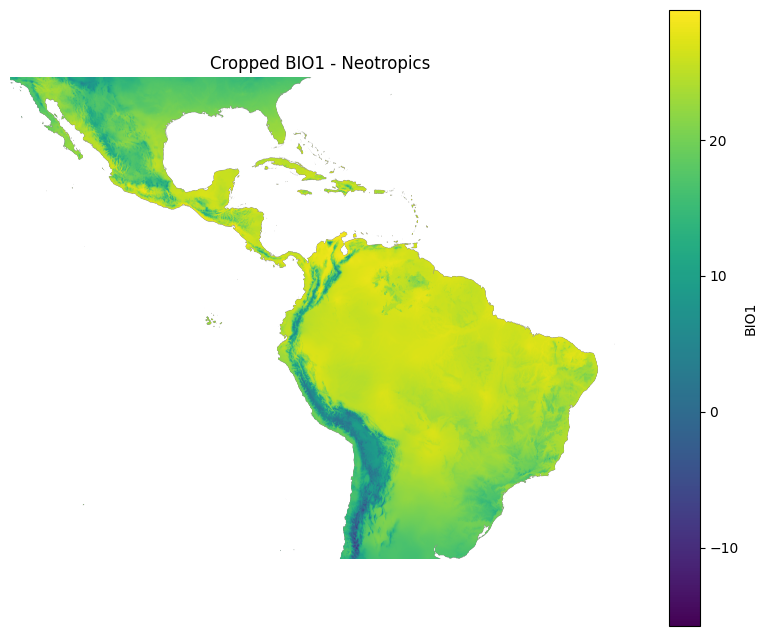

In [ ]:
# Visualize cropped BIO1

import numpy as np
import rasterio
import matplotlib.pyplot as plt

cropped_bio1 = (
    f"{base_dir}/02_data_processed/climate/neotropics/"
    "wc2.1_30s_bio_1.tif"
)

with rasterio.open(cropped_bio1) as src:

    bio1 = src.read(1)

    nodata = src.nodata

bio1 = np.where(bio1 == nodata, np.nan, bio1)

plt.figure(figsize=(10, 8))

plt.imshow(bio1, cmap="viridis")

plt.colorbar(label="BIO1")

plt.title("Cropped BIO1 - Neotropics")

plt.axis("off")

plt.show()

In [ ]:
# Check raster consistency across BIO layers

#import rasterio
#import pandas as pd

#raster_info = []

#for path in cropped_files:

#    with rasterio.open(path) as src:

#        raster_info.append({
#            "file": os.path.basename(path),
#            "width": src.width,
#            "height": src.height,
#            "crs": str(src.crs),
#            "resolution": src.res,
#            "dtype": src.dtypes[0]
#        })

#raster_df = pd.DataFrame(raster_info)

#raster_df

## **2. Add Podostemaceae dataset**

In [ ]:
# Load Podostemaceae occurrence dataset

#import pandas as pd

#occ_path = (
#    f"{base_dir}/04_results/"
#    "Podostemaceae_basins_neotropics.csv"
#)

#df_occ = pd.read_csv(occ_path)

#print(df_occ.shape)

#df_occ.head()

In [ ]:
# Convert occurrences to GeoDataFrame

#import geopandas as gpd
#from shapely.geometry import Point

#gdf_occ = gpd.GeoDataFrame(
#    df_occ,
#    geometry=gpd.points_from_xy(
#        df_occ["Longitude"],
#        df_occ["Latitude"]
#    ),
#    crs="EPSG:4326"
#)

#print(gdf_occ.shape)

#gdf_occ.head()

## **3. Extract BIO1-BIO19 for each occurrency**

In [ ]:
# Extract BIO1–BIO19 values for occurrences
#import glob
#import rasterio
#import numpy as np
#import os

# Copy GeoDataFrame
#gdf_env = gdf_occ.copy()

# Raster files
#cropped_files = sorted(
#    glob.glob(
#        f"{base_dir}/02_data_processed/climate/neotropics/*.tif"
#    )
#)

#for raster_path in cropped_files:

    # Variable name
#    var_name = (
#        os.path.basename(raster_path)
#        .replace(".tif", "")
#        .replace("wc2.1_30s_", "")
#    )

#    print(f"Extracting {var_name}")

#    with rasterio.open(raster_path) as src:

#        coords = [
#            (x, y)
#            for x, y in zip(
#                gdf_env.geometry.x,
#                gdf_env.geometry.y
#            )
#        ]

#        values = [
#            val[0]
#            for val in src.sample(coords)
#        ]

        # Replace nodata values
#        values = [
#            np.nan if v == src.nodata else v
#            for v in values
#        ]

#        gdf_env[var_name] = values

#print("Environmental extraction completed.")

In [ ]:
# Preview environmental matrix

#gdf_env.head()

In [ ]:
# Save environmental occurrence matrix

#output_csv = (
#    f"{base_dir}/04_results/"
#    "Podostemaceae_environmental_matrix.csv"
#)

#gdf_env.drop(columns="geometry").to_csv(
#    output_csv,
#    index=False
#)

#print("Environmental matrix saved.")
#print(output_csv)

## **4. Select BIO variables**

In [ ]:
# Load previously saved environmental matrix

env_matrix_path = (
    f"{base_dir}/04_results/"
    "Podostemaceae_environmental_matrix.csv"
)

gdf_env = pd.read_csv(env_matrix_path)

print(gdf_env.shape)

gdf_env.head()

(3500, 40)


,Species,Country,Department_Province,Locality,Latitude,Longitude,Elevation,River,Subbasin,Basin,...,bio_18,bio_19,bio_2,bio_3,bio_4,bio_5,bio_6,bio_7,bio_8,bio_9
0,NaN,Brazil,Pará,"Nova Mocajuba, rio Caeté, aprox. 3,1 km ao oés...",-1.288750,-46.910367,NaN,NaN,NaN,NaN,...,96.0,670.0,9.166666,79.710144,47.934601,32.299999,20.799999,11.500000,25.799999,26.716667
1,Mourera fluviatilis,French Guiana,Saint-Laurent-du-Maroni,NaN,2.730772,-53.924988,NaN,NaN,NaN,NaN,...,214.0,780.0,9.483334,81.054138,50.915836,32.299999,20.600000,11.699999,25.549999,26.383333
2,Mourera aspera,Brazil,Pr,"APA do Rio da Bulha, Prainha, beira do",-23.928194,-51.832722,311.0,NaN,NaN,NaN,...,532.0,293.0,12.416667,61.468651,300.796906,29.799999,9.600000,20.199999,23.733334,17.683334
3,Apinagia richardiana,Brazil,Pr,"APA do Rio da Bulha, Prainha, beira do",-23.931139,-51.838444,310.0,NaN,NaN,NaN,...,534.0,294.0,12.425000,61.815918,298.733124,29.700001,9.600000,20.100000,23.633333,17.666668
4,Mourera fluviatilis,French Guiana,Saint-Laurent-du-Maroni,NaN,3.913025,-54.261642,NaN,NaN,NaN,NaN,...,263.0,703.0,8.975000,79.424789,53.983353,32.299999,21.000000,11.299999,25.666666,26.700001


In [ ]:
# Select BIO variables only

bio_cols = [
    col for col in gdf_env.columns
    if col.startswith("bio_")
]

bio_df = gdf_env[bio_cols]

print(bio_df.shape)

bio_df.head()

(3500, 19)


,bio_1,bio_10,bio_11,bio_12,bio_13,bio_14,bio_15,bio_16,bio_17,bio_18,bio_19,bio_2,bio_3,bio_4,bio_5,bio_6,bio_7,bio_8,bio_9
0,26.174999,26.883333,25.799999,2338.0,449.0,13.0,77.783241,1178.0,61.0,96.0,670.0,9.166666,79.710144,47.934601,32.299999,20.799999,11.500000,25.799999,26.716667
1,25.733334,26.383333,25.083334,2428.0,352.0,52.0,49.365227,968.0,214.0,214.0,780.0,9.483334,81.054138,50.915836,32.299999,20.600000,11.699999,25.549999,26.383333
2,20.333334,23.733334,16.466667,1480.0,198.0,66.0,37.058201,532.0,250.0,532.0,293.0,12.416667,61.468651,300.796906,29.799999,9.600000,20.199999,23.733334,17.683334
3,20.262501,23.633333,16.416666,1485.0,199.0,67.0,37.173721,534.0,251.0,534.0,294.0,12.425000,61.815918,298.733124,29.700001,9.600000,20.100000,23.633333,17.666668
4,25.912500,26.700001,25.400000,2480.0,375.0,78.0,44.651707,950.0,263.0,263.0,703.0,8.975000,79.424789,53.983353,32.299999,21.000000,11.299999,25.666666,26.700001


In [ ]:
# Select BIO variables

bio_cols = [
    col for col in gdf_env.columns
    if col.startswith("bio_")
]

bio_df = gdf_env[bio_cols]


# Correlation matrix

corr_matrix = bio_df.corr(method="pearson")

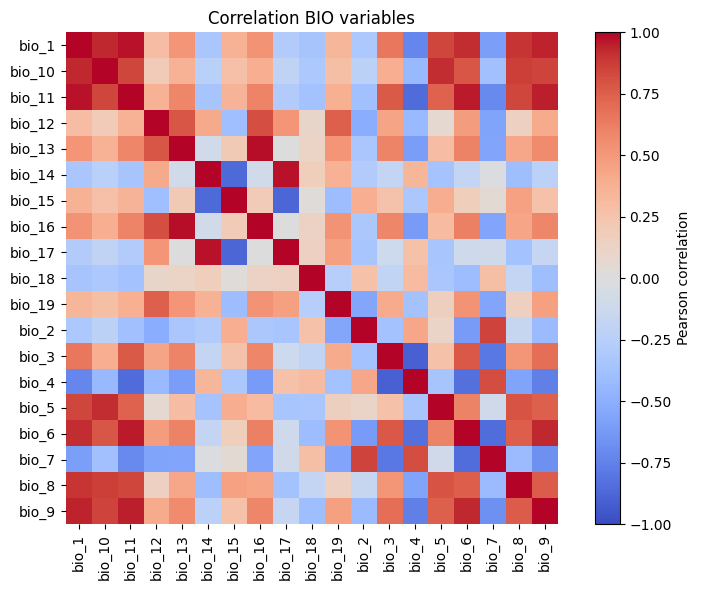

Figure saved:
/content/drive/MyDrive/Podostemaceae/Niche/05_figures/BIO_correlation_heatmap.png


In [46]:
# Plot correlation heatmap

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

ax = plt.gca()

im = ax.imshow(
    corr_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    interpolation="none"
)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.colorbar(im, ax=ax, label="Pearson correlation")

plt.xticks(
    range(len(bio_cols)),
    bio_cols,
    rotation=90
)

plt.yticks(
    range(len(bio_cols)),
    bio_cols
)

plt.title("Correlation BIO variables")

plt.tight_layout()

output_fig = (
    f"{base_dir}/05_figures/"
    "BIO_correlation_heatmap.png"
)

plt.savefig(
    output_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:")
print(output_fig)

In [47]:
# Identify highly correlated variable pairs
# |r| >= 0.85 #commonly use in niche modelling


import pandas as pd
import numpy as np

# Absolute correlation matrix
corr_abs = corr_matrix.abs()

# Keep upper triangle only
upper = corr_abs.where(
    np.triu(
        np.ones(corr_abs.shape),
        k=1
    ).astype(bool)
)

# Extract highly correlated pairs
high_corr_pairs = []

for col in upper.columns:

    for row in upper.index:

        value = upper.loc[row, col]

        if pd.notnull(value) and value >= 0.85:

            high_corr_pairs.append({
                "Variable_1": row,
                "Variable_2": col,
                "Pearson_r": round(value, 3)
            })

# Convert to dataframe
high_corr_df = pd.DataFrame(high_corr_pairs)

# Sort by correlation strength
high_corr_df = high_corr_df.sort_values(
    by="Pearson_r",
    ascending=False
)

high_corr_df.reset_index(drop=True, inplace=True)

high_corr_df

,Variable_1,Variable_2,Pearson_r
0,bio_13,bio_16,0.981
1,bio_14,bio_17,0.976
2,bio_1,bio_11,0.975
3,bio_11,bio_6,0.956
4,bio_11,bio_9,0.946
5,bio_1,bio_9,0.940
6,bio_6,bio_9,0.935
7,bio_1,bio_10,0.934
8,bio_1,bio_6,0.920
9,bio_10,bio_5,0.918


In [ ]:
# @title
# Save highly correlated variable pairs

output_csv = (
    f"{base_dir}/04_results/"
    "highly_correlated_BIO_pairs.csv"
)

high_corr_df.to_csv(
    output_csv,
    index=False
)

print("File saved:")
print(output_csv)

File saved:
/content/drive/MyDrive/Podostemaceae/Niche/04_results/highly_correlated_BIO_pairs.csv


- Variable selection

In [ ]:
# Remove non-selected BIO variables

# Variables retained
selected_bios = [
    "bio_1",
    "bio_4",
    "bio_5",
    "bio_12",
    "bio_13",
    "bio_14"
]

# Variables removed
remove_bios = [
    "bio_2",
    "bio_3",
    "bio_6",
    "bio_7",
    "bio_8",
    "bio_9",
    "bio_10",
    "bio_11",
    "bio_15",
    "bio_16",
    "bio_17",
    "bio_18",
    "bio_19"
]

# Remove variables
gdf_env_selected = gdf_env.drop(
    columns=remove_bios
)

print("Variables removed:")
print(remove_bios)

print("\nVariables retained:")
print(selected_bios)

Variables removed:
['bio_2', 'bio_3', 'bio_6', 'bio_7', 'bio_8', 'bio_9', 'bio_10', 'bio_11', 'bio_15', 'bio_16', 'bio_17', 'bio_18', 'bio_19']

Variables retained:
['bio_1', 'bio_4', 'bio_5', 'bio_12', 'bio_13', 'bio_14']


In [ ]:
# Save final selected environmental matrix

output_csv = (
    f"{base_dir}/04_results/"
    "Podostemaceae_environmental_matrix_bio_selected.csv"
)

gdf_env_selected.drop(
    columns="geometry",
    errors="ignore"
).to_csv(
    output_csv,
    index=False
)

print("Final environmental matrix saved:")
print(output_csv)

Final environmental matrix saved:
/content/drive/MyDrive/Podostemaceae/Niche/04_results/Podostemaceae_environmental_matrix_bio_selected.csv


In [ ]:
# Load final environmental matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_dir = "/content/drive/MyDrive/Podostemaceae/Niche"

final_matrix_path = (
    f"{base_dir}/04_results/"
    "Podostemaceae_environmental_matrix_bio_selected.csv"
)

df_env = pd.read_csv(final_matrix_path)

print(df_env.shape)

df_env.head()

(3500, 27)


,Species,Country,Department_Province,Locality,Latitude,Longitude,Elevation,River,Subbasin,Basin,...,SUB_AREA,UP_AREA,NEXT_DOWN,MAIN_BAS,bio_1,bio_12,bio_13,bio_14,bio_4,bio_5
0,NaN,Brazil,Pará,"Nova Mocajuba, rio Caeté, aprox. 3,1 km ao oés...",-1.288750,-46.910367,NaN,NaN,NaN,NaN,...,18906.2,18906.2,0.000000e+00,6.060008e+09,26.174999,2338.0,449.0,13.0,47.934601,32.299999
1,Mourera fluviatilis,French Guiana,Saint-Laurent-du-Maroni,NaN,2.730772,-53.924988,NaN,NaN,NaN,NaN,...,37696.3,37696.3,6.060123e+09,6.060005e+09,25.733334,2428.0,352.0,52.0,50.915836,32.299999
2,Mourera aspera,Brazil,Pr,"APA do Rio da Bulha, Prainha, beira do",-23.928194,-51.832722,311.0,NaN,NaN,NaN,...,1046.3,15910.2,6.060769e+09,6.060017e+09,20.333334,1480.0,198.0,66.0,300.796906,29.799999
3,Apinagia richardiana,Brazil,Pr,"APA do Rio da Bulha, Prainha, beira do",-23.931139,-51.838444,310.0,NaN,NaN,NaN,...,1046.3,15910.2,6.060769e+09,6.060017e+09,20.262501,1485.0,199.0,67.0,298.733124,29.700001
4,Mourera fluviatilis,French Guiana,Saint-Laurent-du-Maroni,NaN,3.913025,-54.261642,NaN,NaN,NaN,NaN,...,37696.3,37696.3,6.060123e+09,6.060005e+09,25.912500,2480.0,375.0,78.0,53.983353,32.299999


In [ ]:
# Add genus column from Species names

# Extract genus (first word of Species column)
df_env["Genus"] = df_env["Species"].str.split().str[0]

# Move Genus column to first position
cols = ["Genus"] + [
    col for col in df_env.columns
    if col != "Genus"
]

df_env = df_env[cols]

df_env.head()

,Genus,Species,Country,Department_Province,Locality,Latitude,Longitude,Elevation,River,Subbasin,...,SUB_AREA,UP_AREA,NEXT_DOWN,MAIN_BAS,bio_1,bio_12,bio_13,bio_14,bio_4,bio_5
0,NaN,NaN,Brazil,Pará,"Nova Mocajuba, rio Caeté, aprox. 3,1 km ao oés...",-1.288750,-46.910367,NaN,NaN,NaN,...,18906.2,18906.2,0.000000e+00,6.060008e+09,26.174999,2338.0,449.0,13.0,47.934601,32.299999
1,Mourera,Mourera fluviatilis,French Guiana,Saint-Laurent-du-Maroni,NaN,2.730772,-53.924988,NaN,NaN,NaN,...,37696.3,37696.3,6.060123e+09,6.060005e+09,25.733334,2428.0,352.0,52.0,50.915836,32.299999
2,Mourera,Mourera aspera,Brazil,Pr,"APA do Rio da Bulha, Prainha, beira do",-23.928194,-51.832722,311.0,NaN,NaN,...,1046.3,15910.2,6.060769e+09,6.060017e+09,20.333334,1480.0,198.0,66.0,300.796906,29.799999
3,Apinagia,Apinagia richardiana,Brazil,Pr,"APA do Rio da Bulha, Prainha, beira do",-23.931139,-51.838444,310.0,NaN,NaN,...,1046.3,15910.2,6.060769e+09,6.060017e+09,20.262501,1485.0,199.0,67.0,298.733124,29.700001
4,Mourera,Mourera fluviatilis,French Guiana,Saint-Laurent-du-Maroni,NaN,3.913025,-54.261642,NaN,NaN,NaN,...,37696.3,37696.3,6.060123e+09,6.060005e+09,25.912500,2480.0,375.0,78.0,53.983353,32.299999


In [ ]:
# Save environmental matrix with genus column

output_csv = (
    f"{base_dir}/04_results/"
    "Podostemaceae_env_matrix_bio_selected_genus.csv"
)

df_env.to_csv(
    output_csv,
    index=False
)

print("File saved:")
print(output_csv)
print(df_env.columns)

File saved:
/content/drive/MyDrive/Podostemaceae/Niche/04_results/Podostemaceae_env_matrix_bio_selected_genus.csv
Index(['Genus', 'Species', 'Country', 'Department_Province', 'Locality',
       'Latitude', 'Longitude', 'Elevation', 'River', 'Subbasin', 'Basin',
       'Priority', 'Status', 'Date', 'Source', 'GBIF_code', 'HYBAS_ID',
       'PFAF_ID', 'SUB_AREA', 'UP_AREA', 'NEXT_DOWN', 'MAIN_BAS', 'bio_1',
       'bio_12', 'bio_13', 'bio_14', 'bio_4', 'bio_5'],
      dtype='object')


In [ ]:
# Identify BIO variables automatically

bio_vars = [
    col for col in df_env.columns
    if col.startswith("bio_")
]

print(bio_vars)

['bio_1', 'bio_12', 'bio_13', 'bio_14', 'bio_4', 'bio_5']


In [ ]:
# Remove rows with missing climatic values

df_pca = df_env.dropna(
    subset=bio_vars
).copy()

print(df_pca.shape)

(3491, 28)


In [ ]:
# Standardize BIO variables

from sklearn.preprocessing import StandardScaler

X = df_pca[bio_vars]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
# Run PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_scores = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": pca_scores[:, 0],
    "PC2": pca_scores[:, 1],
    "Species": df_pca["Species"].values
})

print(pca.explained_variance_ratio_)

[0.51104105 0.28264652]


In [ ]:
# PCA variable loadings


loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=bio_vars
)

loadings

,PC1,PC2
bio_1,0.518581,-0.193392
bio_12,0.318474,0.618216
bio_13,0.455881,0.332834
bio_14,-0.187710,0.591358
bio_4,-0.478269,-0.000541
bio_5,0.397296,-0.346302


/tmp/ipykernel_8684/3612102713.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  loadings.PC1[i] * 4,
/tmp/ipykernel_8684/3612102713.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  loadings.PC2[i] * 4,
/tmp/ipykernel_8684/3612102713.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  loadings.PC1[i] * 4.2,
/tmp/ipykernel_8684/3612102713.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a 

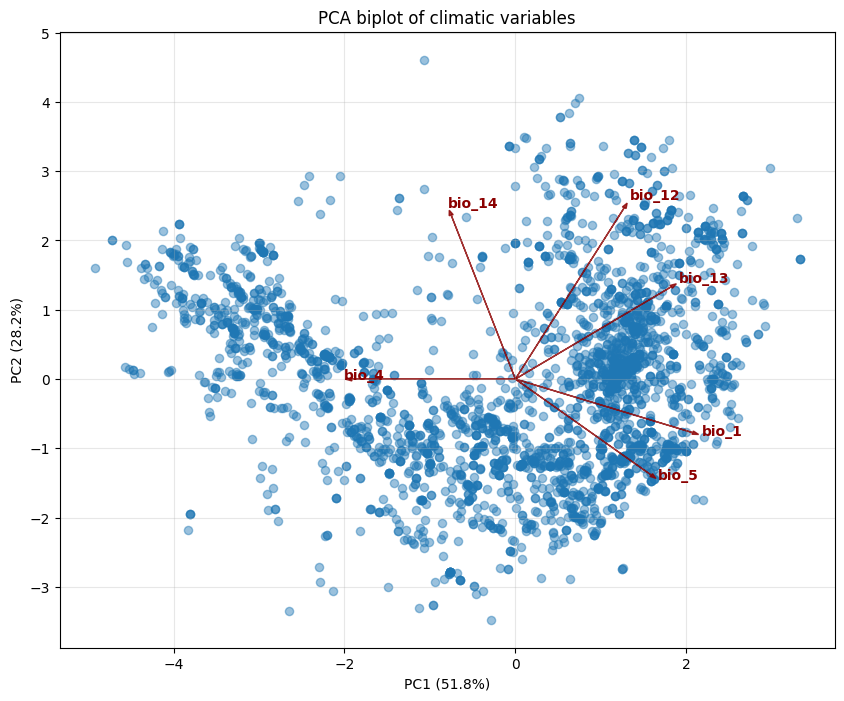

Figure saved:
/content/drive/MyDrive/Podostemaceae/Niche/05_figures/PCA_biplot_selected_BIO.png


In [ ]:
# PCA biplot with BIO variables

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Plot occurrences
plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    s=35,
    alpha=0.45
)

# Plot variable vectors
for i, var in enumerate(bio_vars):

    plt.arrow(
        0, 0,
        loadings.PC1[i] * 4,
        loadings.PC2[i] * 4,
        color="darkred",
        alpha=0.8,
        head_width=0.05
    )

    plt.text(
        loadings.PC1[i] * 4.2,
        loadings.PC2[i] * 4.2,
        var,
        color="darkred",
        fontsize=10,
        fontweight="bold",

    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

plt.title("PCA biplot of climatic variables")

plt.grid(alpha=0.3)

# Save figure
output_fig = (
    f"{base_dir}/05_figures/"
    "PCA_biplot_selected_BIO.png"
)

plt.savefig(
    output_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:")
print(output_fig)

In [ ]:
# Prepare PCA input with Genus before running PCA

df_pca = gdf_env_selected[
    bio_vars + ["Species"]
].dropna().copy()

df_pca["Genus"] = (
    df_pca["Species"]
    .astype(str)
    .str.split()
    .str[0]
)

df_pca = df_pca[
    (df_pca["Genus"].notna()) &
    (df_pca["Genus"] != "") &
    (df_pca["Genus"] != "Podostemaceae")
].copy()

# Standardize BIO variables

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca[bio_vars])

# PCA

pca = PCA(n_components=2)
pca_scores = pca.fit_transform(X_scaled)

# PCA dataframe

pca_df = pd.DataFrame({
    "PC1": pca_scores[:, 0],
    "PC2": pca_scores[:, 1],
    "Genus": df_pca["Genus"].values
})

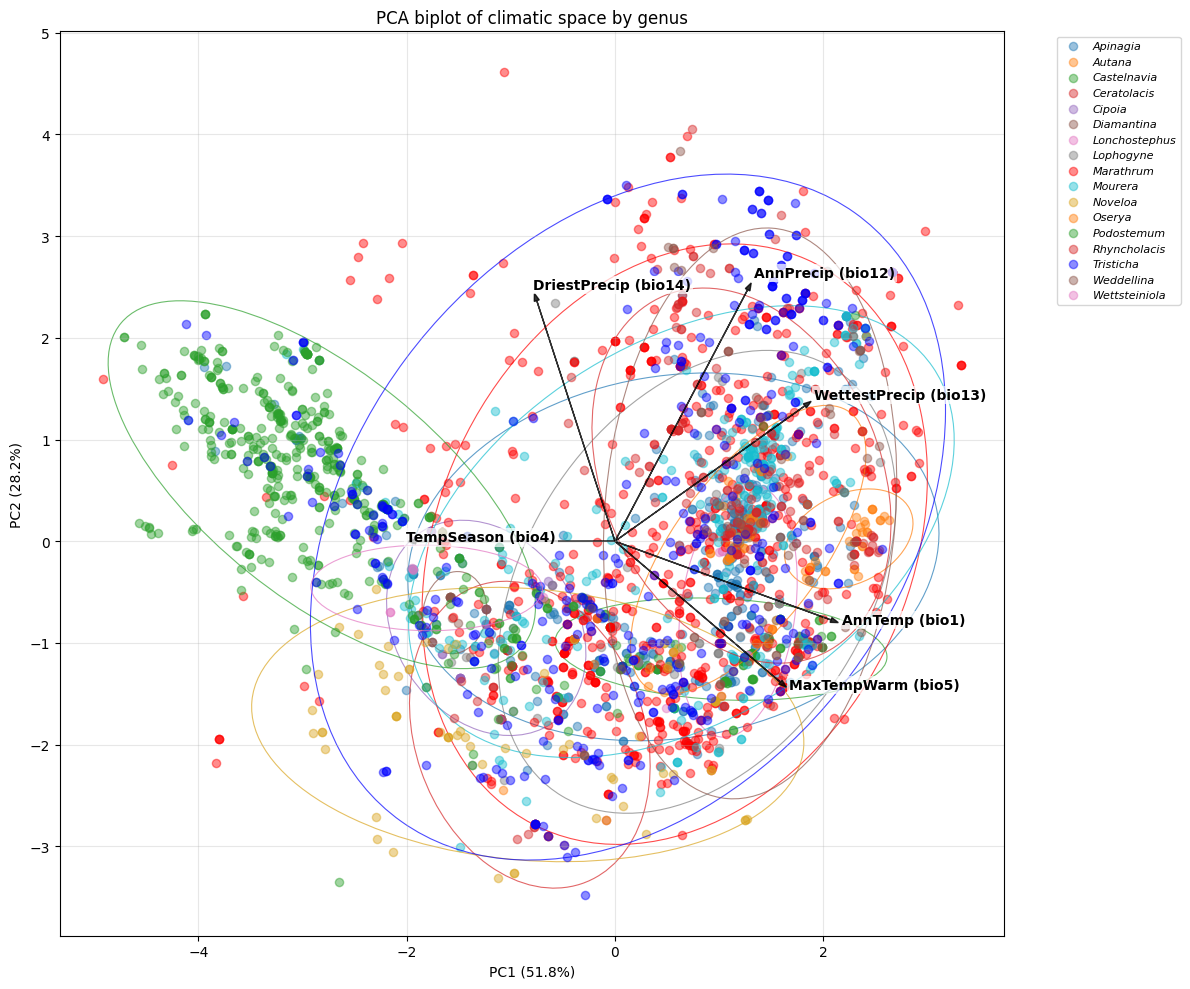

Figure saved:
/content/drive/MyDrive/Podostemaceae/Niche/05_figures/PCA_biplot_by_genus.png


In [ ]:
# PCA biplot colored by genus
# Remove NaN and generic "Podostemaceae"

import pandas as pd
import numpy as np
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt

# --------------------------------------------------
# PCA scores dataframe
# --------------------------------------------------

pca_df = pd.DataFrame({
    "PC1": pca_scores[:, 0],
    "PC2": pca_scores[:, 1],
    "Genus": df_pca["Genus"].values
})

# --------------------------------------------------
# Variable labels
# --------------------------------------------------

var_labels = {
    "bio_1": "AnnTemp (bio1)",
    "bio_4": "TempSeason (bio4)",
    "bio_5": "MaxTempWarm (bio5)",
    "bio_12": "AnnPrecip (bio12)",
    "bio_13": "WettestPrecip (bio13)",
    "bio_14": "DriestPrecip (bio14)"
}

# --------------------------------------------------
# Remove unwanted labels
# --------------------------------------------------

pca_plot = pca_df[
    (~pca_df["Genus"].isna()) &
    (pca_df["Genus"] != "Podostemaceae")
].copy()

# --------------------------------------------------
# Color palette
# --------------------------------------------------

cmap = plt.cm.tab10

genera = sorted(pca_plot["Genus"].unique())

genus_colors = {
    genus: cmap(i % 10)
    for i, genus in enumerate(genera)
}

genus_colors["Tristicha"] = "blue"
genus_colors["Marathrum"] = "red"
genus_colors["Noveloa"] = "goldenrod"

# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure(figsize=(12, 10))

for genus in sorted(pca_plot["Genus"].unique()):

    subset = pca_plot[
        pca_plot["Genus"] == genus
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=35,
        alpha=0.45,
        label=genus,
        color=genus_colors[genus]
    )

  # Add ellipse around each genus
    if len(subset) >= 3:

        x = subset["PC1"].values
        y = subset["PC2"].values

        cov = np.cov(x, y)

        eigenvalues, eigenvectors = np.linalg.eigh(cov)

        order = eigenvalues.argsort()[::-1]
        eigenvalues = eigenvalues[order]
        eigenvectors = eigenvectors[:, order]

        angle = np.degrees(
            np.arctan2(
                eigenvectors[1, 0],
                eigenvectors[0, 0]
            )
        )

        ellipse = Ellipse(
            xy=(np.mean(x), np.mean(y)),
            width=2 * np.sqrt(eigenvalues[0]) * 2,
            height=2 * np.sqrt(eigenvalues[1]) * 2,
            angle=angle,
            edgecolor=genus_colors[genus],
            facecolor="none",
            linewidth=0.8,
            alpha=0.7
        )

        plt.gca().add_patch(ellipse)

# Plot BIO vectors
for i, var in enumerate(bio_vars):

    plt.arrow(
        0,
        0,
        loadings.PC1.iloc[i] * 4,
        loadings.PC2.iloc[i] * 4,
        color="black",
        alpha=0.8,
        head_width=0.05
    )

    plt.text(
        loadings.PC1.iloc[i] * 4.2,
        loadings.PC2.iloc[i] * 4.2,
        var_labels.get(var, var),
        fontsize=10,
        fontweight="bold",
        color="black",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.7,
            pad=1.5
        )
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

plt.title("PCA biplot of climatic space by genus")

plt.grid(alpha=0.3)

# Italic legend
legend = plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

for text in legend.get_texts():
    text.set_fontstyle("italic")

plt.tight_layout()

# Save figure
output_fig = (
    f"{base_dir}/05_figures/"
    "PCA_biplot_by_genus.png"
)

plt.savefig(
    output_fig,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:")
print(output_fig)